In [153]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [154]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [155]:
len(words)

32033

In [156]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [157]:
# build the dataset

block_size = 3 # context lenght: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
olivia
ava
isabella
sophia


In [158]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [159]:
C = torch.randn((27, 2))

In [160]:
emb = C[X] # embedding for each 3-tuple that we have in X
emb.shape

torch.Size([32, 3, 2])

In [161]:
X[13]

tensor([0, 0, 1])

In [162]:
print(C[0])
print(C[1])

tensor([ 0.8485, -0.5035])
tensor([ 1.1337, -0.6350])


In [163]:
emb[13]

tensor([[ 0.8485, -0.5035],
        [ 0.8485, -0.5035],
        [ 1.1337, -0.6350]])

In [164]:
W1 = torch.randn((6, 100)) # dimension_of_inputs x neurons on first layer
b1 = torch.randn(100)

In [165]:
# three ways to get the same result
print(torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape)
print(torch.cat(torch.unbind(emb, 1), 1).shape)
print(emb.view(32, 6).shape)

torch.Size([32, 6])
torch.Size([32, 6])
torch.Size([32, 6])


In [166]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [167]:
h

tensor([[ 0.9739, -0.6289, -0.8763,  ..., -0.6343,  0.9605,  0.9964],
        [ 0.9905, -0.7803, -0.8135,  ..., -0.8913,  0.9694,  0.9961],
        [ 0.5424, -0.3064, -0.9743,  ...,  0.8636,  0.9978,  0.9993],
        ...,
        [ 0.9722, -0.9809, -0.1801,  ...,  0.1487,  0.5898,  0.3219],
        [ 0.7379, -0.3770, -0.8384,  ...,  0.5482,  0.7903,  0.9804],
        [ 0.9970, -0.8292, -0.6232,  ..., -0.8758, -0.9126,  0.5301]])

In [168]:
h.shape

torch.Size([32, 100])

In [169]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [170]:
logits = h @ W2 + b2

In [171]:
logits.shape

torch.Size([32, 27])

In [172]:
counts = logits.exp()

In [173]:
prob = counts / counts.sum(1, keepdims=True)

In [174]:
prob.shape

torch.Size([32, 27])

In [175]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.5913)

In [176]:
# ------------ now made respectable ------------

In [177]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [178]:
g = torch.Generator().manual_seed(27) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [179]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [180]:
for p in parameters:
    p.requires_grad = True

In [181]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [182]:
lri = []
lossi = []

for i in range(1000):

    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

# print(loss.item())

In [183]:
# plt.plot(lri, lossi)

In [184]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(0.2925, grad_fn=<NllLossBackward0>)

In [185]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [186]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context lenght: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [622]:
# ------------ now made respectable ------------

In [623]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [624]:
g = torch.Generator().manual_seed(27) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [625]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [626]:
for p in parameters:
    p.requires_grad = True

In [627]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [628]:
lri = []
lossi = []
stepi = []

In [629]:
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())

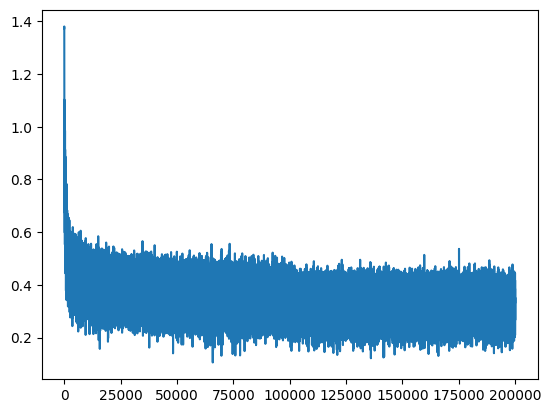

In [630]:
plt.plot(stepi, lossi)

In [631]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1126, grad_fn=<NllLossBackward0>)

In [632]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1538, grad_fn=<NllLossBackward0>)

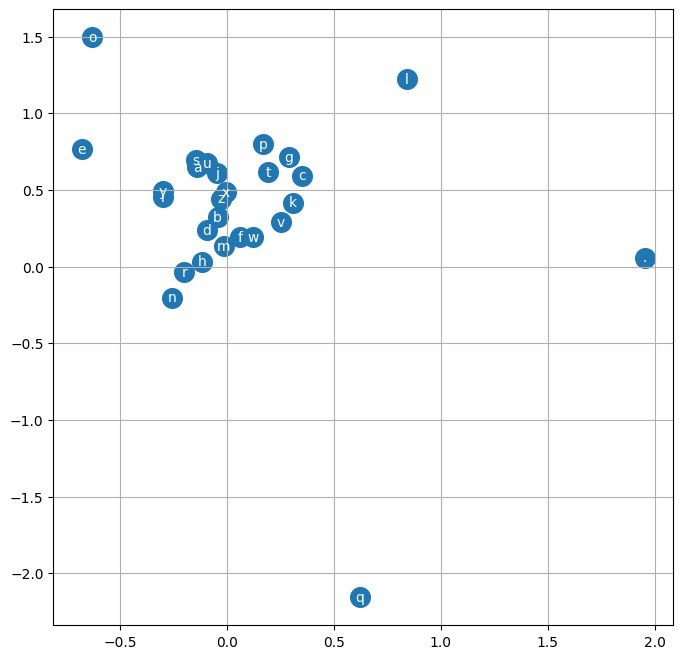

In [ ]:
# if the embbeding is only 2 dimensions
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [634]:
# sample from the model
g = torch.Generator().manual_seed(27)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

shon.
albaralein.
brish.
roen.
turce.
blaith.
chricie.
gitrymair.
emica.
deet.
klaia.
arbelle.
jainnerelbenno.
mara.
adra.
sulvin.
idy.
har.
surel.
kalezmaelaya.
